**Building a Simple Neural Network**

This is the first lab of course PyTorch for Deep Learning

**Goal**


*   Build and train first neural network with a single neuron that learn patterns from data to make predictions.

****

**Scenario:**
You're a bike delivery person with a 7-mile delivery order. Your company promises delivery in under 30 minutes, and one more late delivery would put your job at risk.
*****
We will:
- Prepare delivery data, the distance and time from past orders
- Build a simple neural network using PyTorch (just 1 neuron)
- Train it to find the relationship between distance and delivery time
- Predict whether you can make that 7-mile delivery in time





# **Imports**



In [1]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/PyTorch_for_DeepLearning')

import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils



#This line ensures that your results are reproducible and consistent everyime.
torch.manual_seed(42)

*Try to understand the role of manual_seed by the code below*

In [2]:
import torch

print("Without manual seed:")
print(torch.rand(1))
print(torch.rand(1))

print("\nHas manual seed = 42:")
torch.manual_seed(42)
print(torch.rand(1))

print("\nreset manual seed with same value = 42:")
torch.manual_seed(42)
print(torch.rand(1))

print("\nreset manual seed with different value = 64:")
torch.manual_seed(64)
print(torch.rand(1))


Without manual seed:
tensor([0.8823])
tensor([0.9150])

Has manual seed = 42:
tensor([0.8823])

reset manual seed with same value = 42:
tensor([0.8823])

reset manual seed with different value = 64:
tensor([0.0492])


#The Machine Learning Pipeline in Action

##Stage 1&2: Data Ingestion and Preparation

* Define the two essential tensors for the task:
  *  the distance tensor contains how far you biked for 4 recent deliveries (in miles)
  * the times tensor shows how long the delivery took (in minutes)
  * dtype=torch.float32 sets your data type to 32-bit floating point values for precise calculations


In [3]:
#Distance in miles for recent bike deliveries
distances = torch.tensor([[1.0],[2.0],[3.0],[4.0]], dtype=torch.float32)

#Corresponding delivery times in minutes
times = torch.tensor([[6.96],[12.11],[16.77],[22.22]], dtype=torch.float32)

# Stage 3: Model Building

For bike deliveries,you'll assume a linear relationship between distance and time, a reasonable starting point. Your model will be a single neuron that learns this relationship.

A linear equation: Time = W x Distance + B

The model job is to find the best values for the weight (W) and bias (B) that fit the deliveries data.

We'll use nn.Sequential(nn.Linear(1,1)) to create linear model
* nn.Linear(1,1): the first 1 means that it take 1 input (distance), and the 2nd 1 means 1 neuron that is producing 1 output (predicted time)
* nn.Sequential: help us to add layer to neuron network following an other. In this example we have only 1 layer, the linear layer so we don't see much of it yet.

In [4]:
#Create a model with 1 input (distance) and one output (time)
model = nn.Sequential(nn.Linear(1,1))


# Stage 4: Training

Time to train the neural network. In this case 1 model of 1 linear layer of 1 neuron 😼

We will need two key tools to help the model learn from the data
* **Loss Function**: nn.MSELoss which is Mean Squared Error loss function. It measures how wrong the prediction are. The model has a goal to minimise the loss.
* **Optimizer**: optim.SD sets up the Stochastic Gradient Descent optimizer. It adjusts the weight and bias parameters based on the loss. lr = 0.01 is the *learning rate* which defines how big each adjustment step is.  

In [5]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

Now it's time for the model to learn. The training loop is where the model cycles through the data repeatedly, gradually discovering the relationship between distance and delivery time.

We'll train for 500 epochs (an epoch = a complete pass through the data). During each epoch, these following things occur:



1.   `optimizer.zero_grad()`: Clears gradients from previous round. Without this, PyTorch would accumulate adjustments, which could break the learning process.
2.   `outputs = model(distances)`: Perform the "forward pass", where the model makes predictions based on the input distances.
3.   `loss = loss_function(outputs, times)`: Calculates how wrong the predicted outputs are by comparing them to actual delivery times.
4.   `loss.backward()`: The "backward pass" (backpropagation) is performed, which calculates exactly how to adjust the weight and bias to reduce the error
5.   `optimizer.step()`: Update the model's parameters using those calculated adjustment in step 4.
6.   the `loss` is printed every 50 epocs to allow tracking the model's learning progress and the error decrease.  



In [6]:
# Training loop
for epoch in range (500):
  # Reset the optimizer's gradient
  optimizer.zero_grad()

  # Make predictions (forward pass)
  outputs = model(distances)

  # Calculate the loss
  loss = loss_function(outputs, times)

  # Calculate the adjustment by backward propagation (backward pass)
  loss.backward()

  # Update the model parameter
  optimizer.step()

  # Print loss every 50 epochs
  if (epoch +1) % 50 ==0:
    print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 0.10756294429302216
Epoch 100: Loss = 0.0864570289850235
Epoch 150: Loss = 0.07082214206457138
Epoch 200: Loss = 0.05923750251531601
Epoch 250: Loss = 0.05065387487411499
Epoch 300: Loss = 0.044294361025094986
Epoch 350: Loss = 0.039582230150699615
Epoch 400: Loss = 0.03609074279665947
Epoch 450: Loss = 0.03350376710295677
Epoch 500: Loss = 0.03158711642026901


# Visualising the Training Result

After trained, we can plot the model predictions as a line againts actual delivery data (distance, time)


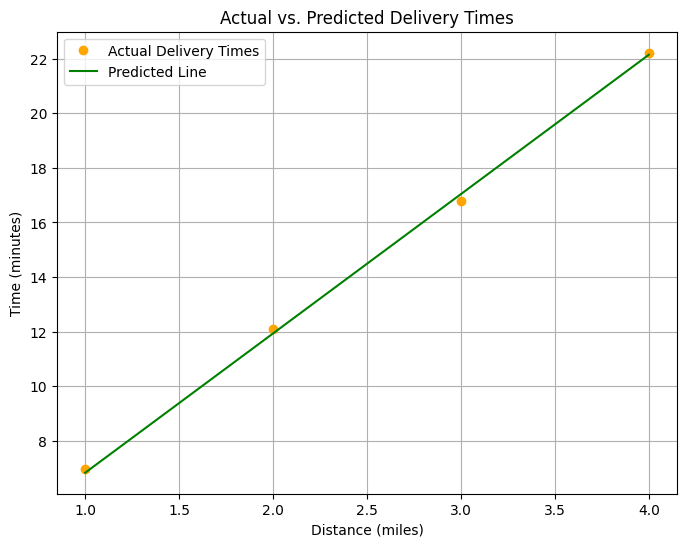

In [7]:
helper_utils.plot_results(model, distances, times)

# Make The Prediction
Now model is trained. Can it answer question: can we make the appointment 7-mile delivery in under 30 minutes?

In [8]:
distance_to_predict = 7.0


In [9]:
with torch.no_grad():
  # Convert the variable to the 2D PyTorch tensor that model expects
  new_distance = torch.tensor([[distance_to_predict]], dtype=torch.float32)

  # Pass the new data to the trained model to get a prediction
  predicted_time = model(new_distance)

  # Use .item() to extract the scalar value from the tensor for printing
  print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time.item():.1f} minutes")

  # Use the scalar value in a conditional statement to make the final decision
  if predicted_time.item() > 30:
    print("\nDecision: Do NOT take the job. You will likely be late.")
  else:
    print("\nDecision: Take the job. You can make it!")


Prediction for a 7.0-mile delivery: 37.5 minutes

Decision: Do NOT take the job. You will likely be late.


# Inspecting the Model learning

In [10]:
# Access the first (and only) layer in the sequential model
layer = model[0]

# Get weights and bias
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f"Weight: {weights}")
print(f"Bias: {bias}")

Weight: [[5.1054373]]
Bias: [1.7243671]


# Testing the model on more complex data

In [11]:
# Combined dataset: bikes for short distances, cars for longer ones
new_distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
new_times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

Now let's see how well the model handles this new mixed dataset
- we will use the trained model to predict the times for new distances

In [12]:
# Use the already trained linear model to make predictions
with torch.no_grad():
  predicted_times = model(new_distances)

- Calculate `new_loss`bewteen model's prediction and actual times
- Notice how the loss value will be significantly higher than the loss at the end of the training. This will indicate a poor fit.

In [13]:
# Calculate the new_loss
new_loss = loss_function(predicted_times, new_times)

# Print the new_loss
print(f"New Loss: {new_loss.item()}")

New Loss: 169.36282348632812


*Plot the model and the data to see the differences and here we can see that the model is performing not that well due to we are using a linear prediction model*


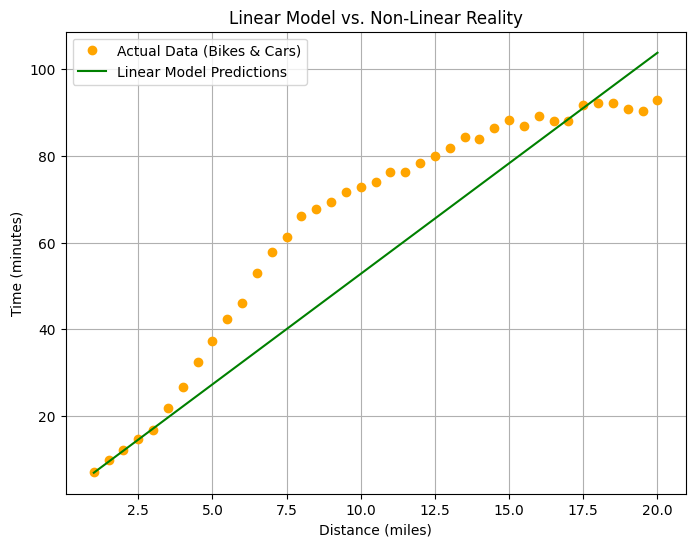

In [14]:
helper_utils.plot_nonlinear_comparison(model, new_distances, new_times)

In [15]:
import os
print(os.getcwd())


/content


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# A New Step: Normalizing the Data

As we now have data set that contains delivery times for bikes and cars vs distances. Which the trained linear model did not work well on.

What we will do next is to apply a quick data preparation step called Normalization. This is a standard technique that makes the training process more stable and effective by adjusting the scale of data. This adjustment helps prevent large distance values from dominating the learning process and keeps gradients stable during training.

* We will calculate the mean and standard deviation for the distances and times tensors
* We will then apply standardization to each tensor using its respective mean and standard deviation, which creates new normalised tensors name `distances_norm`and `times_norm`.
* This specific technique is called standardization (or z-score normalization), which converts the original data from `1.0 to 20.0 miles` and approximately `7 to 93 minutes` into a new, normalised scale.


In [17]:
# Calculate the mean and standard deviation for the 'distances' tensor
distances_mean = new_distances.mean()
distances_std = new_distances.std()

# Caclculate the mean and standard deviation for the 'times' tensor
times_mean = new_times.mean()
times_std = new_times.std()

# Apply standardization to the distance
distances_norm = (new_distances - distances_mean) / distances_std

# Apply standardization to the times
times_norm = (new_times - times_mean) / times_std


* Plot data to understand values of the normalised distances and times

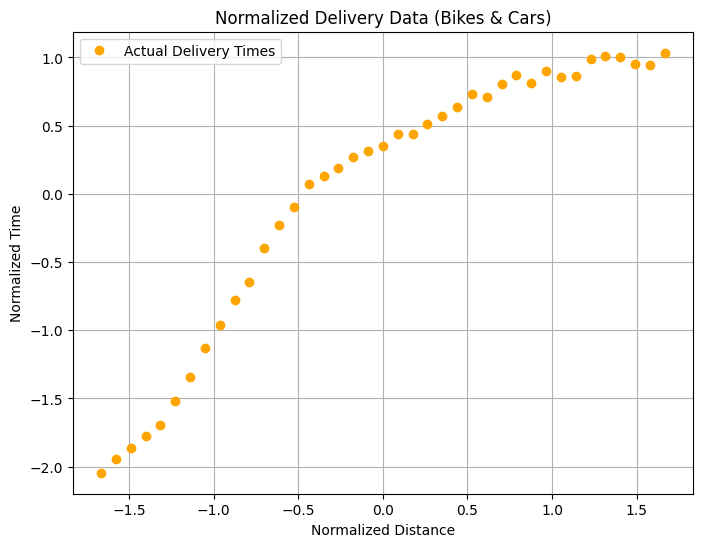

In [18]:
helper_utils.plot_data(distances_norm, times_norm, normalize=True)

# Building the Non-Linear Model

With normalised data, we can now build a model capable of learning its curved pattern. We can define the model's architecture, which now includes a `ReLU`activation function. This structure what gives the model the ability to learn non-linear relationships.

* `nn.Linear(1,3)`: This is the **first hidden layer**. It consists of 3 neurons, each receiving 1 input feature (the normalized distance). This layer transforms the single output value into 3 separate values.
* `nn.ReLU()`: applies the `ReLU activation function` to the ouput of each of the 3 neurons from hidden layer. This is the crucial non-linear step that allows the model to create "bends" and learn curves instead of just straight lines.
* `nn.Linear(3,1)`: This is the **output layer**. It takes 3 output values from previous step as its input and combines them to produce a single final output, which is the predicted (normalized) delivery time.

So, we are creating a neural network with 1 hidden layer containing 3 neurons.

In [19]:
# This line ensures that the results are reproducible and consistent every time.
torch.manual_seed(27)

# Non-linear model initiate
model_nl = nn.Sequential(
    nn.Linear(1,3),
    nn.ReLU(),
    nn.Linear(3,1)
)

# Training the Non-Linear Model

* Define the loss function and the optimizer for training

In [20]:
# Define the loss function and optimizer
loss_function_nl = nn.MSELoss()
optimizer_nl = optim.SGD(model_nl.parameters(), lr=0.01)

With the model and training tools ready, we can begin the training process.
 * We will run the training loop for `3000` epochs (more than Lab 1, `500 times` because the non-linear pattern is more complex and requires more training). This will repeatedly feed the normalized data to the model, measure the error, and adjust the model's parameters to improve its predictions.
 * Then we will add live-plot, allowing us to watch in real time as the model's prediction line adapts to fit the cureved data. This live-plot helps us see how the model gradually learns to fit the curve, starting with a poor fit and improving overtime.  

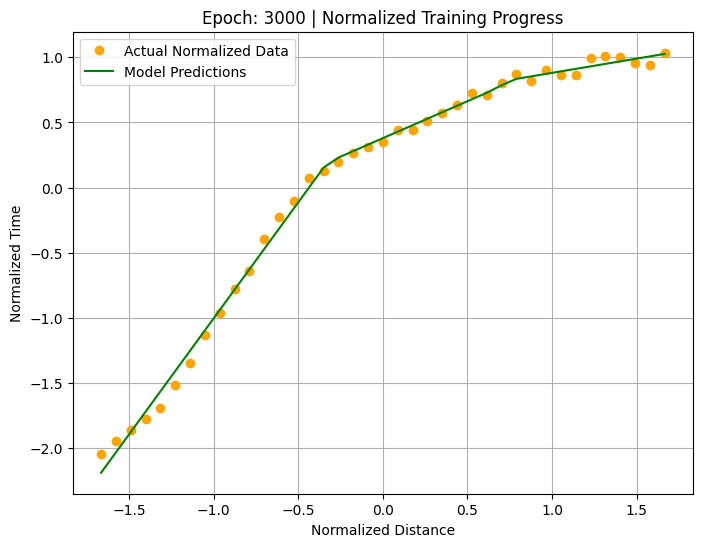


Training Complete.

Final Loss: 0.00314371008425951


In [21]:
# Training loop
for epoch in range (3000):
  # Reset the opmizizer's gradients
  optimizer_nl.zero_grad()

  # Make predictions (forward pass)
  outputs = model_nl(distances_norm)

  # Calculate the loss
  loss = loss_function_nl(outputs, times_norm)

  # Calculate the adjustments (backward pass)
  loss.backward()

  # Update the model's parameters
  optimizer_nl.step()

  # Create a live plot every 50 epochs
  if (epoch + 1) % 50 == 0:
    helper_utils.plot_training_progress(
        epoch= epoch,
        loss = loss,
        model = model_nl,
        distances_norm = distances_norm,
        times_norm = times_norm
    )
print("\nTraining Complete.")
print(f"\nFinal Loss: {loss.item()}")


# Checking the Final Fit
Now that training is complete, we will visualize the result

* We will plot the model's final predicted curve againts the original data points.
* This will let us visually inspect how wel lthe non-linear model learned to fit the complex data pattern.

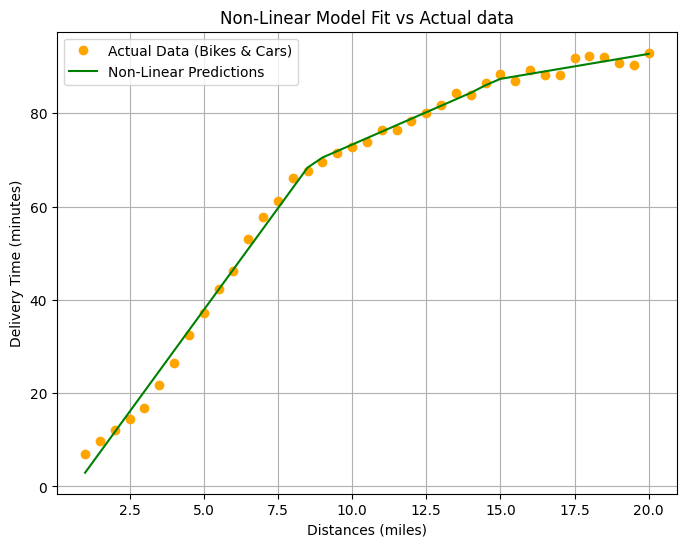

In [22]:
helper_utils.plot_final_fit(model_nl, new_distances, new_times, distances_norm, times_std, times_mean)

# Making a Prediction

With the trained non-linear model, we can use it to make a prediction for a new delivery.

However, we have trained the model on **normalized data** so below is the steps we need to do to use the trained model correctly.

* Take the new input distance and **normalize** it using the same mean and standard deviation from the training data.
* After the model provide the prediction, we have to de-normalize the output.
* Finally, based on the denormalized output, make a decision of which vehicle to use.

In [23]:
# Distance to predict in miles.
distance_to_predict = 5.1

In [24]:
# Use the torch.no_grad() context manager for efficient prediction
with torch.no_grad():
  # Normalize the input distance
  distance_tensor = torch.tensor([[distance_to_predict]], dtype = torch.float32)
  new_distance_norm = (distance_tensor - distances_mean) / distances_std

  # Get the normalized prediction from the model
  predicted_time_norm = model_nl(new_distance_norm)

  # De-normalize the output to get the actual delivery time in minutes
  predicted_time = predicted_time_norm * times_std + times_mean

  # Decision making logic
  print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time.item():1f} minutes")

  # First, check if the delivery is possible within 45-minute timeframe
  if predicted_time.item() > 45:
    print("\nDecision: Do NOT take the job. You will likely be late.")
  else:
    # Determin the vehicle for delivery base on distance
    if distance_to_predict <= 3:
      print(f"Decision: Take a bike. It will only take {predicted_time.item():.1f} minutes.")
    else:
      print(f"Decision: Take a car. It will take {predicted_time.item():.1f} minutes.")

Prediction for a 5.1-mile delivery: 38.694336 minutes
Decision: Take a car. It will take 38.7 minutes.
